In [440]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

In [441]:
#data input
data1=np.array([0,2,0.8,0.23,0.5,0.89,1.23,-0.23,-1.4,0])
data2=np.array([-0.73,0.45,-0.12,0.87,-0.56,0.34,-0.22,0.91,-0.04,0.67])
N1=len(data1)
N2=len(data2)
print(N1,N2)

10 10


In [442]:
# sort data to simplify matters
def sort(data):
    data=deepcopy(data)
    while True: #sort the data
        swaped=False
        for i in range(N1-1):
            if data[i]>data[i+1]:
                data[i],data[i+1]=data[i+1],data[i]
                swaped=True
        if not swaped:
            break
    return data
sdata1=sort(data1)
sdata2=sort(data2)

In [443]:
print(data1)
print(sdata1)

[ 0.    2.    0.8   0.23  0.5   0.89  1.23 -0.23 -1.4   0.  ]
[-1.4  -0.23  0.    0.    0.23  0.5   0.8   0.89  1.23  2.  ]


In [444]:
def median(data):
    data=deepcopy(data)
    N=len(data)
    if N//2:
        median=(data[N//2+1]+data[N//2])/2
    else:
        median=(data[(N+1)//2])
    return median

def M(data,k): #kth central moment
    # central moments has lots of use,
    # for example: (--> means related to)
    # k=0-->total
    # k=1-->mean, k=2-->variance
    # k=3-->skewness, k=4-->kurtosis
    data=deepcopy(data)
    Mk=0
    for i in data:
        Mk+=(i)**k
    return Mk

In [445]:
# the real formula to different statistical values
# mainly descripes values of data1
# data2 assisting in explanation
weighted_total=M(data1,0)
med=median(sdata1)
mean=M(data1,1)/N1
var=M(data1-mean*np.ones(N1),2)/(N1) #(N1-1) for incomplete data,N1 for complete data
sd=np.sqrt(var)
skew=M((data1-mean*np.ones(N1))/var,3)/N1
kurt=M((data1-mean*np.ones(N1))/var,4)/N1-3

In [446]:
#cases when median is used 
ADev=M(abs(data1-med),1)/N1 # average deviation

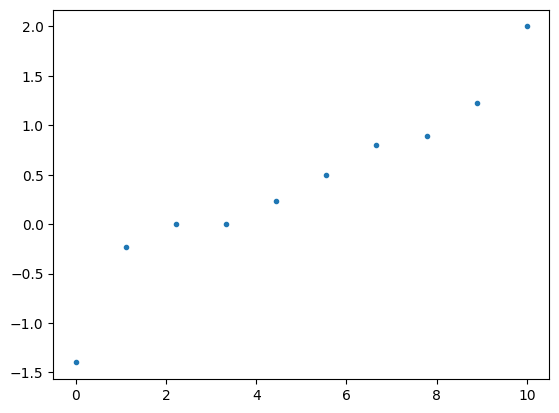

In [447]:
# find the median by graph
x=np.linspace(0,N1,N1)
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(x,sdata1,'.')
plt.show()

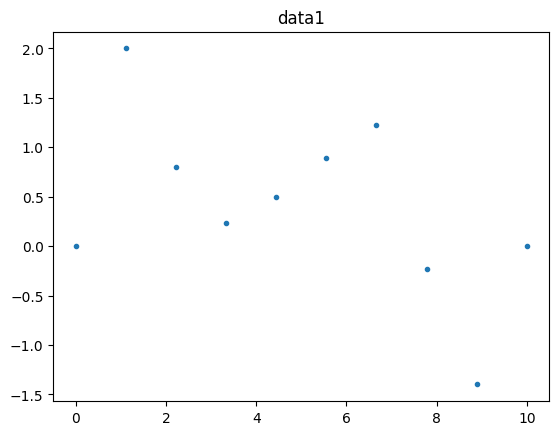

In [448]:
#get the pricture of the data1
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(x,data1,'.')
ax.set_title('data1')
plt.show()

In [449]:
#output the exact value
print('weighted_sum= ',weighted_total)
print('median= ',med)
print('mean= ',mean)
print('var= ',var)
print('standard deviation= ',sd)
print('skewness= ',skew)
print('kurtosis= ',kurt)
print('average_deviation= ',ADev)

weighted_sum=  10.0
median=  0.65
mean=  0.40199999999999997
var=  0.7644759999999999
standard deviation=  0.8743431820515328
skewness=  -0.31568101615768707
kurtosis=  2.2202456995616995
average_deviation=  0.712


In [450]:
#corrected variance using bionomial thm
aproxvar=(M((data1-mean*np.ones(N1)),2)-(M((data1-mean*np.ones(N1)),1)**2)/N1)/(N1-1)
print('approximated variance= ',aproxvar)

approximated variance=  0.8494177777777776


In [451]:
# values related to 
# comparison between multisets of data

# introduce the idea of standard score
def SS(dataset,new_data):
    data=deepcopy(dataset)
    N=len(data)
    data_mean=M(data,1)/N
    data_sd=np.sqrt(M(data1-mean*np.ones(N1),2)/(N1-1))
    ss=(new_data-data_mean)/data_sd
    return ss

# introduce the degree of freedom (df) of a data
df1=N1-1
df2=N2-1
print(df1,df2)

9 9


In [452]:
#all values of data2
weighted_total2=M(data2,0)
med2=median(sdata2)
mean2=M(data2,1)/N2
var2=M(data2-mean2*np.ones(N2),2)/(N2-1) #(N2-1) for incomplete data,N2 for complete data
sd2=np.sqrt(var2)
skew2=M((data2-mean2*np.ones(N2))/var2,3)/N1
kurt2=M((data2-mean2*np.ones(N2))/var2,4)/N1-3

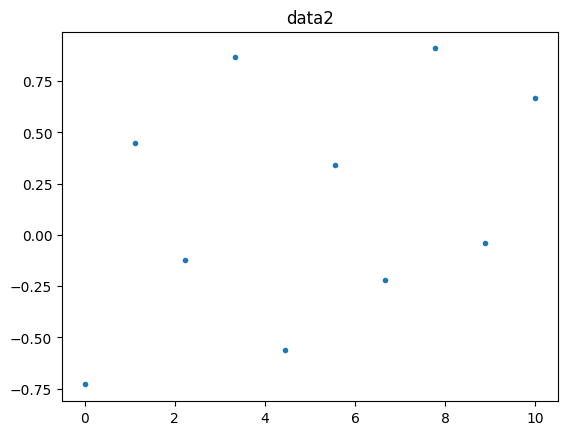

In [453]:
x2=np.linspace(0,N2,N2)
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(x2,data2,'.')
ax.set_title('data2')
plt.show()

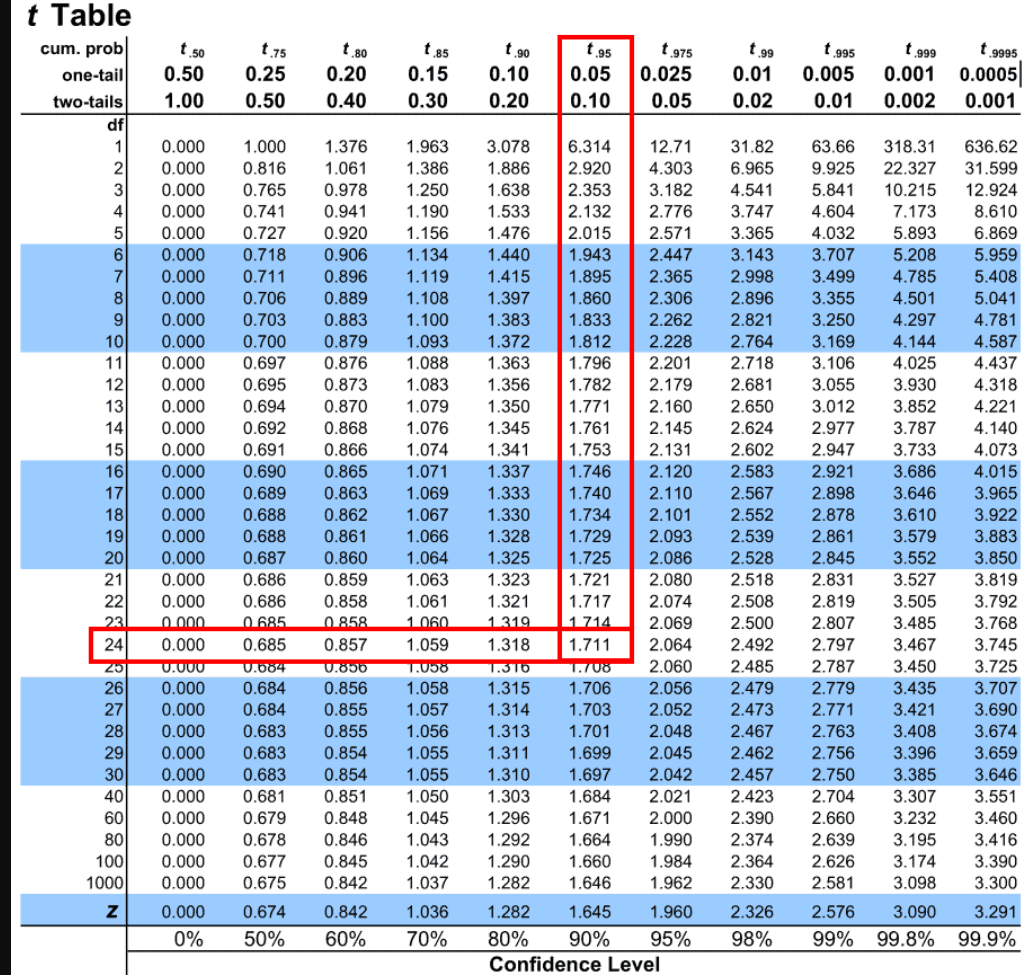

In [454]:
# the following cells tries to answer whether 2 sets of data
# are from the same distribution

# the significance of mean difference
# by t-test
# limit1:the data sets should be in normal distribution
# limit2:the data sets should not have great variance difference

t=abs(mean-mean2)/np.sqrt(sd**2/N1+sd2**2/N2)
print('the data for t-test:')
print(t,N1+N2-2)


the data for t-test:
0.7388261660971301 18


In [455]:
# the null hypothesis: There are no statistical difference in the means of these 2 set of data
# from the t-table, crit. val. =2.101
# As the t-value < crit.val., we accept the null hypothesis that the means are the same

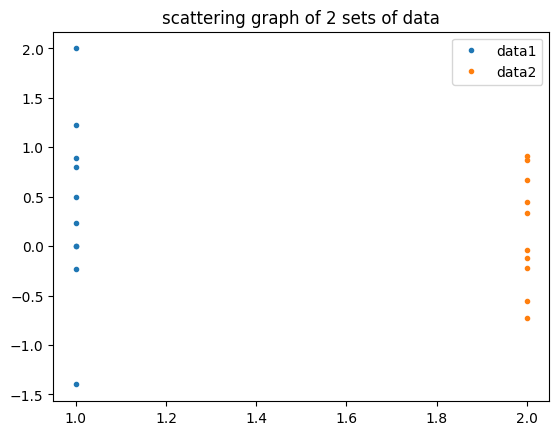

In [456]:
# the significance of variance difference
# by F-test(ANOVA test)
# (warning: this test is usually done among multi-sets of data, but 2 here)
# before running into the test, let's build a scattering graph
x1=np.ones(N1)
x2=2*np.ones(N2)
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(x1,data1,'.',label='data1')
ax.plot(x2,data2,'.',label='data2')
ax.set_title('scattering graph of 2 sets of data')
ax.legend()
plt.show()

In [457]:
# from the graph intuitively, x-axis does not do any effect on y-axis

In [458]:
combdata=np.append(data1,data2)
Ncomb=len(combdata)

# calculate the mean of all data:
totmean=M(combdata,1)/Ncomb
print('total mean=',totmean)

# calculate the Sum of Square Total (SST)
sst=M(combdata-totmean*np.ones(Ncomb),2)
print('sum of square total=',sst)
totdf=Ncomb-1 #(total number of data)-1(the totmean)

# calculate the Sum of Square Within (SSW)
ssw=var*(N1-1)+var2*(N2-1)
print('sum of square within=',ssw)
wdf=Ncomb-2 #(total number of data)-2(the 2 means of each set of data)

# calculate the Sum of Square Between (SSB)
ssb=M((mean-totmean)*np.ones(N1),2)+M((mean2-totmean)*np.ones(N2),2)
print('sum of square between=',ssb)
bdf=1 #2(total number of means)-1(the total mean)

#check if ssb+ssw=sst (thm), obviously totdf=wdf+bdf
print(np.isclose(ssb+ssw,sst))

f=(ssb/bdf)/(ssw/wdf)
print('F-value=',f)
#F-value varies from 0 to inf, the larger it is, the greater effect x-axis does on y-axis

total mean= 0.27949999999999997
sum of square total= 10.961295
sum of square within= 9.896694
sum of square between= 0.300125
False
F-value= 0.5458641037097842


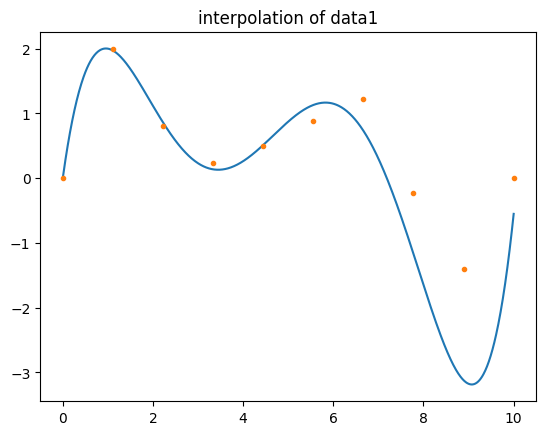

RMSE= 5.56198154112043
MAE= 2.4240799484208106


In [459]:
# the root mean square error, which estimates the error bound
# when you input a new data with the old data.
# the smaller both values are, the more perfect the model is

def rho(x): #interpolation of data1
    return 2*x-0.96167*x*(x-1)+0.2*x*(x-1)*(x-3)-0.03535*x*(x-1)*(x-3)*(x-6)+0.00577*x*(x-1)*(x-3)*(x-6)*(x-8)

xpts=np.linspace(0,10,1001)

fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(xpts,rho(xpts))
ax.plot(x,data1,'.')
ax.set_title('interpolation of data1')
plt.show()

RMSE=M((rho(data1)-data1),2)
RMSE/=N1
RMSE=np.sqrt(RMSE)
print('RMSE=',RMSE)

# the mean absolute error (MAE), an alternative for RMSE
MAE=M(abs(rho(data1)-data1),1)
MAE/=N1
print('MAE=',MAE)

In [460]:
# the correlation formula (r-test) measures how are the data related to each other
# ranging from [-1,1], the greater the magnitude is, the more related the datas are
# similar to the lst square formula
# -1:totally iversely proportional, 1:totally proportional

r=0
for i in range(N1):
    r+=(data1[i]-mean)*(data2[i]-mean2)
r/=sd*sd2
print(r)

# reproduce the t-value
# this t is to test whether data1 is a good predicter of data2
tr=r*np.sqrt((N1-2)/(1-r**2))
print(tr)

-0.05598787532512549
-0.15860640750814256


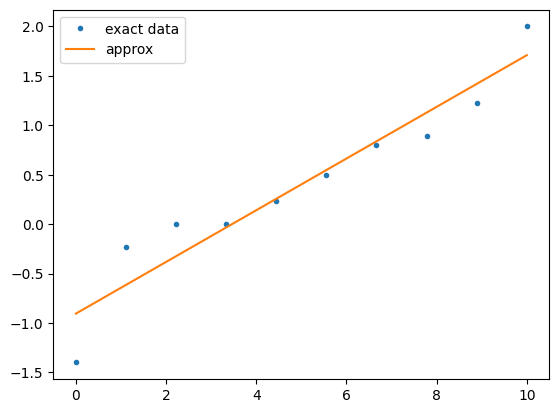

In [461]:
# the linear fit

y=sdata1
meany=mean.copy()
x=np.linspace(0,N1,N1)
meanx=M(x,1)/N1
varx=M(x-meanx*np.ones(N1),2)/N1

m=M((y-meany*np.ones(N1))*(x-meanx*np.ones(N1)),1)
m/=varx*N1
c=meany-m*meanx
yapprox=m*x+c

fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(x,y,'.',label='exact data')
ax.plot(x,yapprox,label='approx')
ax.legend()
plt.show()

In [462]:

# everything in the oop format so that the code is even more simple

class Stat:
    
    'analyse the statistics for a given set of data'
    
    def __init__(self,data):
        self.data=data
        self.N=len(self.data)
        self.mean=M(self.data,1)/self.N
        self.var=M((self.data-self.mean*np.ones(self.N)),2)/self.N  #again, N for compete set of data, N-1 for uncomplete set of data
        self.sd=np.sqrt(self.var)
        self.skew=M((self.data-self.mean*np.ones(self.N)/self.var),3)/self.N
        self.kurt=M((self.data-self.mean*np.ones(self.N)/self.var),4)/self.N-3
        self.ADev=median(self.data)
        self.sdata=sort(self.data)
        self.median=median(self.data)
        
    def __str__(self):
        return "number of data: {:d}\nmean={:.4f}\nvar={:.4f}\nsd={:.4f}\nskew={:.4f}\nkurt={:.4f}\nadev={:.4f}\nmedian={:.4f}".format(self.N,self.mean,
                                               self.var,self.sd,
                                               self.skew,self.kurt,
                                               self.ADev,
                                               self.median)
    
    def fig(self):
        x=np.linspace(0,self.N,self.N)
        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.plot(x,self.data,'.',color='blue',label='data')
        ax.plot(x,self.sdata,'.',color='orange',label='sorted data')
        ax.legend()
        plt.show()
    

number of data: 10
mean=0.4020
var=0.7645
sd=0.8743
skew=-0.4270
kurt=-1.0766
adev=1.0600
median=1.0600


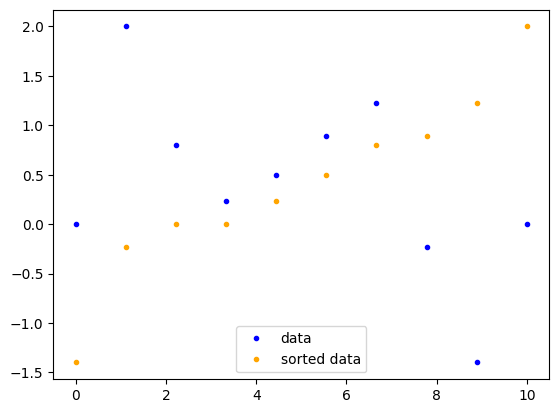

In [463]:
data1=Stat(np.array([0,2,0.8,0.23,0.5,0.89,1.23,-0.23,-1.4,0]))
print(data1)
data1.fig()